# <p style="font-family: Cambria; text-align: center; font-size: 44px;">IV. PREDICTIVE ANALYSIS</p>



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())

Dataset shape: (2008, 210)
Unique patients: 2008


<p style="font-family: Cambria; font-size: 16px;"><b>Shared helper functions and chart colours</b></p>

In [17]:
def build_logistic_model(features, categorical_features):

    # Keep only categorical columns included in the feature list
    categorical_features = [
        col for col in categorical_features
        if col in features
    ]

    # Remaining columns are treated as numeric
    numeric_features = [
        col for col in features
        if col not in categorical_features
    ]

    transformers = []

    # -----------------------------
    # Numeric preprocessing
    # -----------------------------
    if numeric_features:

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            )
        )

    # -----------------------------
    # Categorical preprocessing
    # -----------------------------
    if categorical_features:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    # -----------------------------
    # Preprocessor
    # -----------------------------
    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    # -----------------------------
    # Final ML pipeline
    # -----------------------------
    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    return model


print("\nPredictive analysis setup completed successfully!")


Predictive analysis setup completed successfully!


In [18]:
cols = ["#6daa9f", "#774571", "#6daa9f", "#774571"]   # palette used in Q9-Q12

# ---------- Same colour system as the descriptive notebook ----------
INK, MUTED, GRID = "#1f1f1f", "#6b6b6b", "#e6e6e6"
BLUE    = "#2a78d6"   # single series, and "Readmission"
ORANGE  = "#eb6834"   # second series, and "Death"
REF     = "#d03b3b"   # reference lines only (coin-toss line, cut-offs)
NEUTRAL = "#b8b6b0"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
def ramp(n):
    """n evenly spaced steps from the blue ramp (light -> dark)."""
    return [RAMP[i] for i in np.linspace(0, len(RAMP) - 1, n).round().astype(int)]

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#bdbdbd", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "legend.frameon": False})

def label_bars(ax, fmt="{:.1f}%"):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9, color=INK)

def suptitle(fig, text):
    fig.suptitle(text, fontsize=14, fontweight="bold", x=0.06, ha="left", y=1.02)

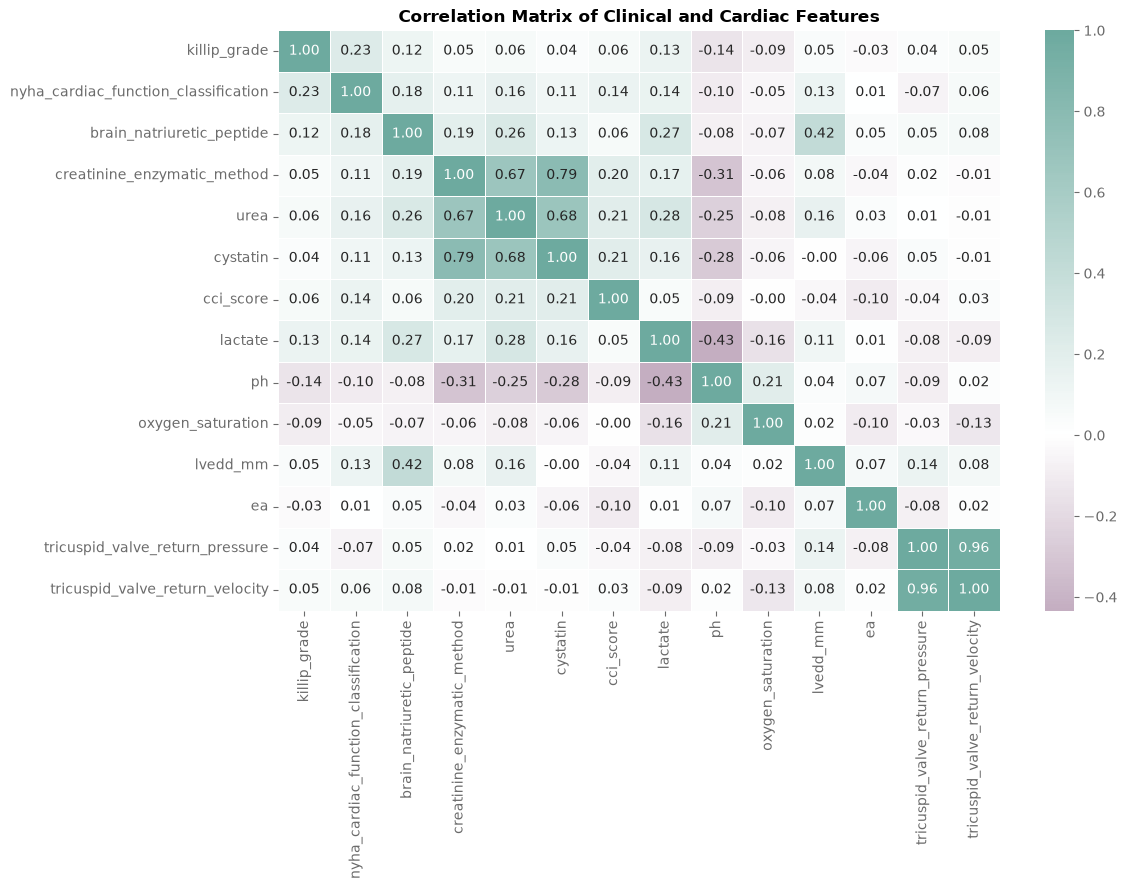

In [19]:
# Examining a Correlation Matrix of All Features

# Admission-time clinical and cardiac features
corr_features = [
    "killip_grade",
    "nyha_cardiac_function_classification",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "urea",
    "cystatin",
    "cci_score",
    "lactate",
    "ph",
    "oxygen_saturation",
    "lvedd_mm",
    "ea",
    "tricuspid_valve_return_pressure",
    "tricuspid_valve_return_velocity"
]

corr_data = df[corr_features].apply(pd.to_numeric, errors="coerce").corr()

cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#774571", "white", "#6daa9f"]
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Clinical and Cardiac Features")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The correlation matrix shows the strength and direction of relationships among the selected clinical and cardiac features. Most features have weak-to-moderate correlations, indicating that they capture different aspects of patient condition. Some stronger relationships can be observed among related cardiac and renal measurements, suggesting overlapping clinical information. Overall, the matrix helps identify related variables and potential multicollinearity before building predictive models.</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q1. Can demographic characteristics such as age, gender, weight, height, BMI, and occupation be used to predict the risk of in-hospital mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>weight</code>, <code>height</code>, <code>bmi</code>, <code>occupation</code>, <code>outcome_during_hospitalization</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Demographic characteristics may contain information related to mortality risk, but they do not directly measure heart-failure severity. This question tests whether age group, gender, body measurements and occupation can distinguish patients who die during hospitalization from those who survive. Because in-hospital mortality is rare, a class-balanced Logistic Regression model is used and performance is interpreted using ROC-AUC, recall, precision, F1-score and the confusion matrix rather than accuracy alone.
</i></b></p>


In [20]:
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

features_q1 = ["agecat", "gender", "weight", "height", "bmi", "occupation"]
X1 = df[features_q1]
y1 = df["in_hospital_death"]

num1 = ["weight", "height", "bmi"]
cat1 = ["agecat", "gender", "occupation"]

prep1 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num1),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat1)
])

model_q1 = Pipeline([
    ("preprocessor", prep1),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

model_q1.fit(X1_train, y1_train)
pred1 = model_q1.predict(X1_test)
prob1 = model_q1.predict_proba(X1_test)[:, 1]
auc1 = roc_auc_score(y1_test, prob1)

print("In-hospital deaths:", int(y1.sum()), "of", len(y1))
print(classification_report(y1_test, pred1, zero_division=0))
print("ROC-AUC:", round(auc1, 3))
print("Confusion Matrix:\n", confusion_matrix(y1_test, pred1))

In-hospital deaths: 11 of 2008
              precision    recall  f1-score   support

           0       1.00      0.71      0.83       600
           1       0.02      1.00      0.03         3

    accuracy                           0.71       603
   macro avg       0.51      0.86      0.43       603
weighted avg       1.00      0.71      0.83       603

ROC-AUC: 0.91
Confusion Matrix:
 [[428 172]
 [  0   3]]


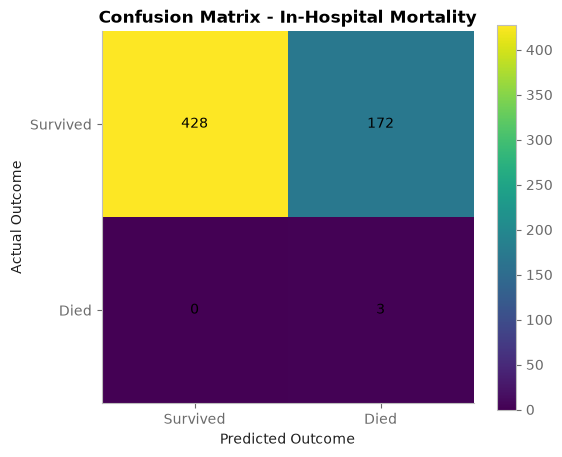

In [21]:
# Confusion Matrix Heatmap
cm1 = confusion_matrix(y1_test, pred1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Survived", "Died"])
ax.set_yticklabels(["Survived", "Died"])
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")
ax.set_title("Confusion Matrix - In-Hospital Mortality")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm1[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The confusion matrix shows that the demographic model correctly identified all 3 in-hospital deaths in the test set, but it also incorrectly classified 172 surviving patients as deaths. Although the model achieved a ROC-AUC of 0.910 and mortality recall of 1.00, mortality precision was only 0.02. This means the model was sensitive to the very small death group but generated many false-positive alerts. Because only 11 of 2,008 patients died during hospitalization, demographic characteristics alone should be treated as exploratory predictors and are not sufficient as a reliable standalone mortality model.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q2. Can demographic and baseline clinical characteristics be used to predict the risk of 28-day mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>bmi</code>, <code>admission_way</code>, <code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>lvef</code>, <code>systolic_blood_pressure</code>, <code>pulse</code>, <code>cci_score</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Twenty-eight-day mortality reflects short-term risk after hospitalization. Demographics alone may not capture the patient's clinical condition, so this model adds admission type, cardiac severity, LVEF, systolic blood pressure, pulse and comorbidity burden. The objective is to determine whether this combined baseline profile can distinguish patients who die within 28 days from those who survive.
</i></b></p>


In [22]:
features_q2 = [
    "agecat", "gender", "bmi", "admission_way",
    "nyha_cardiac_function_classification", "killip_grade",
    "lvef", "systolic_blood_pressure", "pulse", "cci_score"
]
X2 = df[features_q2]
y2 = df["death_within_28_days"]

num2 = ["bmi", "nyha_cardiac_function_classification", "killip_grade",
        "lvef", "systolic_blood_pressure", "pulse", "cci_score"]
cat2 = ["agecat", "gender", "admission_way"]

prep2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat2)
])

model_q2 = Pipeline([
    ("preprocessor", prep2),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

model_q2.fit(X2_train, y2_train)
pred2 = model_q2.predict(X2_test)
prob2 = model_q2.predict_proba(X2_test)[:, 1]
auc2 = roc_auc_score(y2_test, prob2)

print("28-day deaths:", int(y2.sum()), "of", len(y2))
print(classification_report(y2_test, pred2, zero_division=0))
print("ROC-AUC:", round(auc2, 3))
print("Confusion Matrix:\n", confusion_matrix(y2_test, pred2))

28-day deaths: 37 of 2008
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       592
           1       0.05      0.55      0.10        11

    accuracy                           0.81       603
   macro avg       0.52      0.68      0.49       603
weighted avg       0.97      0.81      0.88       603

ROC-AUC: 0.771
Confusion Matrix:
 [[483 109]
 [  5   6]]


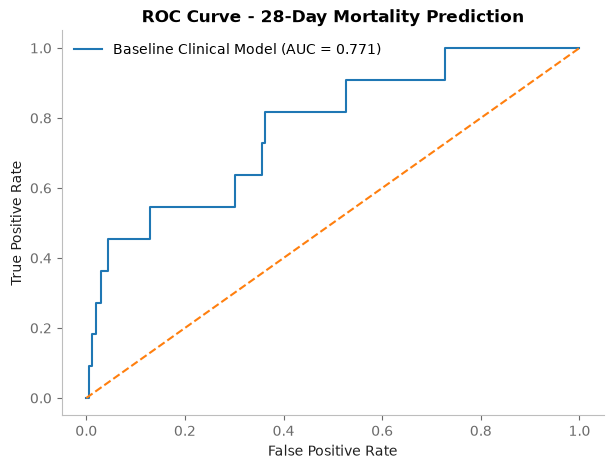

In [23]:
# ROC Curve
fpr2, tpr2, _ = roc_curve(y2_test, prob2)

plt.figure(figsize=(7, 5))
plt.plot(fpr2, tpr2, label=f"Baseline Clinical Model (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 28-Day Mortality Prediction")
plt.legend()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The ROC curve shows that the combined demographic and baseline clinical model achieved a ROC-AUC of 0.771 for predicting 28-day mortality, indicating useful but not strong discrimination between patients who died and those who survived. The model correctly identified 6 of the 11 deaths in the test set, giving a mortality recall of 0.55, but precision was only 0.05 because many surviving patients were also classified as high risk. These results suggest that demographics, cardiac severity, vital signs and comorbidity together provide some predictive information for short-term mortality, but the small number of deaths means the model should be interpreted cautiously.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q3. Can NYHA functional class and Killip grade together predict 28-day mortality better than either heart-failure severity measure alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
NYHA functional class and Killip grade measure different aspects of heart-failure severity. Three predictive models are compared: NYHA alone, Killip alone, and NYHA plus Killip. All models use the same train/test split so their ROC-AUC values can be compared fairly. If the combined model performs better, it suggests that the two severity measures provide complementary predictive information.
</i></b></p>


In [24]:
y3 = df["death_within_28_days"]

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.30, random_state=42, stratify=y3
)

def severity_model(features):
    X = df[features]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y3.iloc[train_idx], y3.iloc[test_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    return model, probability, roc_auc_score(y_test, probability)

nyha_model, nyha_prob, nyha_auc = severity_model(
    ["nyha_cardiac_function_classification"]
)
killip_model, killip_prob, killip_auc = severity_model(
    ["killip_grade"]
)
combined_model, combined_prob, combined_auc = severity_model(
    ["nyha_cardiac_function_classification", "killip_grade"]
)

results_q3 = pd.DataFrame({
    "Model": ["NYHA", "Killip", "NYHA + Killip"],
    "ROC-AUC": [nyha_auc, killip_auc, combined_auc]
})
display(results_q3.round(3))

,Model,ROC-AUC
0,NYHA,0.694
1,Killip,0.772
2,NYHA + Killip,0.807


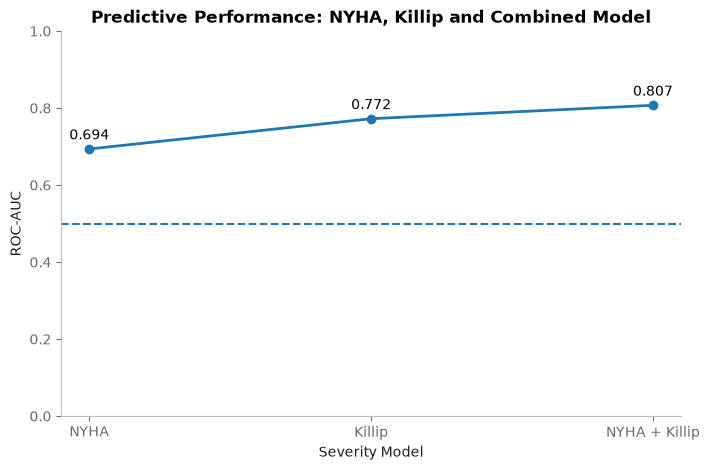

In [25]:
# Line chart comparing the three severity models
plt.figure(figsize=(8, 5))
plt.plot(
    results_q3["Model"],
    results_q3["ROC-AUC"],
    marker="o",
    linewidth=2
)
plt.axhline(0.5, linestyle="--")
plt.ylabel("ROC-AUC")
plt.xlabel("Severity Model")
plt.title("Predictive Performance: NYHA, Killip and Combined Model")
plt.ylim(0, 1)

for x, y in zip(results_q3["Model"], results_q3["ROC-AUC"]):
    plt.text(x, y + 0.025, f"{y:.3f}", ha="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The model-comparison chart shows that NYHA alone produced a ROC-AUC of 0.694, Killip grade alone produced 0.772, and the combined NYHA + Killip model produced the highest ROC-AUC at 0.807. The combined model improved AUC by 0.113 compared with NYHA alone and by 0.035 compared with Killip alone. This suggests that NYHA and Killip provide complementary information for predicting 28-day mortality, with the combined severity model showing the strongest discrimination of the three in this test split.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q4. Can renal-function markers predict 6-month mortality and 6-month readmission in patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>creatinine_enzymatic_method</code>, <code>urea</code>, <code>uric_acid</code>, <code>glomerular_filtration_rate</code>, <code>cystatin</code>, <code>acute_renal_failure</code>, <code>moderate_to_severe_chronic_kidney_disease</code>, <code>death_within_6_months</code>, <code>re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Kidney dysfunction commonly accompanies severe heart failure and may provide prognostic information. Creatinine, urea, uric acid, GFR and cystatin represent different aspects of renal function, while acute renal failure and moderate-to-severe chronic kidney disease represent diagnosed renal impairment. Separate prediction models are built for 6-month mortality and 6-month readmission to determine whether a renal-only profile can discriminate both outcomes.
</i></b></p>


In [26]:
renal_features = [
    "creatinine_enzymatic_method", "urea", "uric_acid",
    "glomerular_filtration_rate", "cystatin",
    "acute_renal_failure", "moderate_to_severe_chronic_kidney_disease"
]

def renal_model(outcome):
    X = df[renal_features]
    y = df[outcome]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    return model, y_test, pred, prob, auc

mort_model4, mort_y4, mort_pred4, mort_prob4, mort_auc4 = renal_model(
    "death_within_6_months"
)
readm_model4, readm_y4, readm_pred4, readm_prob4, readm_auc4 = renal_model(
    "re_admission_within_6_months"
)

results_q4 = pd.DataFrame({
    "Outcome": ["6-Month Mortality", "6-Month Readmission"],
    "ROC-AUC": [mort_auc4, readm_auc4]
})
display(results_q4.round(3))

print("\n6-Month Mortality")
print(classification_report(mort_y4, mort_pred4, zero_division=0))
print("\n6-Month Readmission")
print(classification_report(readm_y4, readm_pred4, zero_division=0))

,Outcome,ROC-AUC
0,6-Month Mortality,0.586
1,6-Month Readmission,0.576



6-Month Mortality
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       586
           1       0.07      0.41      0.12        17

    accuracy                           0.82       603
   macro avg       0.52      0.62      0.51       603
weighted avg       0.95      0.82      0.88       603


6-Month Readmission
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       371
           1       0.45      0.47      0.46       232

    accuracy                           0.58       603
   macro avg       0.56      0.56      0.56       603
weighted avg       0.58      0.58      0.58       603



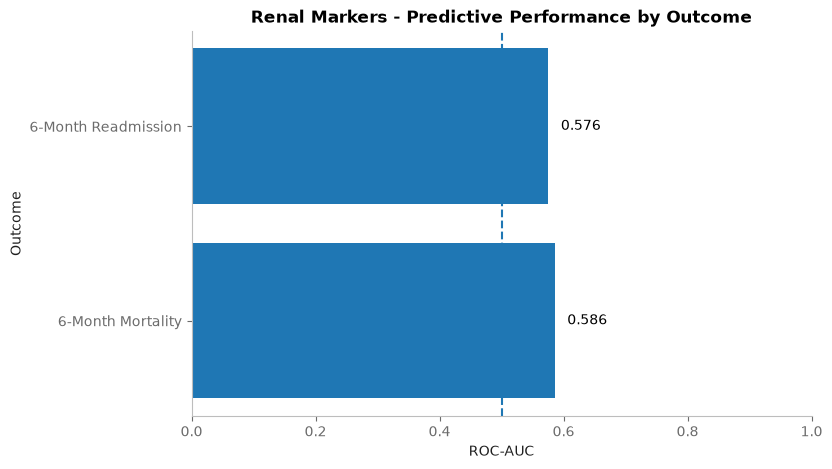

In [27]:
# Horizontal bar chart comparing renal-model performance
plt.figure(figsize=(8, 5))
plt.barh(results_q4["Outcome"], results_q4["ROC-AUC"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("ROC-AUC")
plt.ylabel("Outcome")
plt.title("Renal Markers - Predictive Performance by Outcome")
plt.xlim(0, 1)

for i, value in enumerate(results_q4["ROC-AUC"]):
    plt.text(value + 0.02, i, f"{value:.3f}", va="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The horizontal bar chart shows that renal-function markers produced a ROC-AUC of 0.586 for 6-month mortality and 0.576 for 6-month readmission. Both values are only slightly above the 0.50 reference level, indicating weak predictive discrimination when renal markers are used alone. The mortality model performed only marginally better than the readmission model, with an AUC difference of 0.010. These results suggest that renal markers may contribute useful risk information, but they are not strong standalone predictors and would be better combined with cardiac severity, biomarkers, comorbidities and other clinical characteristics.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q5. Do cardiac biomarkers such as BNP and troponin improve mortality prediction beyond demographic and clinical characteristics alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>agecat, gender, pulse, systolic_blood_pressure, nyha_cardiac_function_classification, killip_grade, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>BNP reflects cardiac wall stress and fluid overload, while high-sensitivity troponin reflects myocardial injury. Demographic characteristics, vital signs and heart-failure severity already provide useful clinical information, so the objective is to determine whether these cardiac biomarkers add predictive value beyond the baseline clinical profile. Two models are compared: a baseline demographic and clinical model and an expanded model that adds BNP and troponin. ROC-AUC and precision-recall performance are used to evaluate whether the additional biomarker information improves mortality prediction.</b></i></p>

In [28]:
target_q5 = "death_within_6_months"

baseline_q5 = [
    "agecat",
    "gender",
    "pulse",
    "systolic_blood_pressure",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

expanded_q5 = baseline_q5 + [
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin"
]

categorical_q5 = [
    "agecat",
    "gender",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

q5 = df[expanded_q5 + [target_q5]].copy()

q5[target_q5] = pd.to_numeric(
    q5[target_q5], errors="coerce"
)

q5 = q5.dropna(subset=[target_q5])

X_q5 = q5[expanded_q5]
y_q5 = q5[target_q5].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_q5,
    y_q5,
    test_size=0.25,
    random_state=42,
    stratify=y_q5
)

baseline_model_q5 = build_logistic_model(
    baseline_q5,
    categorical_q5
)

expanded_model_q5 = build_logistic_model(
    expanded_q5,
    categorical_q5
)

baseline_model_q5.fit(
    X_train[baseline_q5],
    y_train
)

expanded_model_q5.fit(
    X_train[expanded_q5],
    y_train
)

prob_base_q5 = baseline_model_q5.predict_proba(
    X_test[baseline_q5]
)[:, 1]

prob_full_q5 = expanded_model_q5.predict_proba(
    X_test[expanded_q5]
)[:, 1]

results_q5 = pd.DataFrame({
    "Model": [
        "Clinical Baseline",
        "Clinical + BNP + Troponin"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, prob_base_q5),
        roc_auc_score(y_test, prob_full_q5)
    ],
    "PR_AUC": [
        average_precision_score(y_test, prob_base_q5),
        average_precision_score(y_test, prob_full_q5)
    ]
})

display(results_q5.round(3))

,Model,ROC_AUC,PR_AUC
0,Clinical Baseline,0.706,0.111
1,Clinical + BNP + Troponin,0.739,0.102


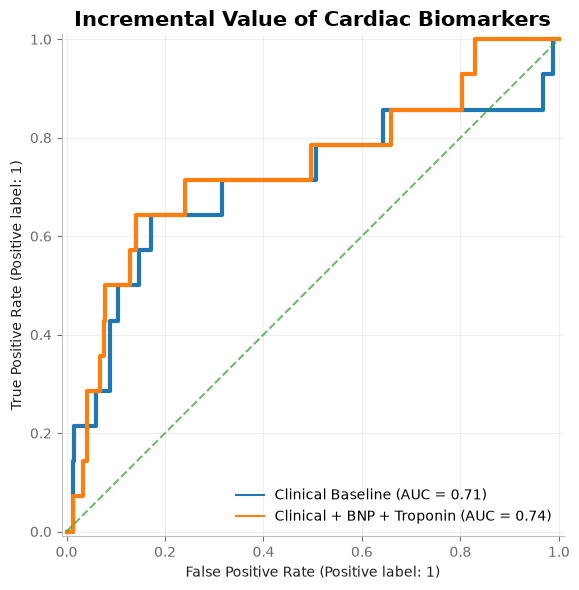

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))

display_base = RocCurveDisplay.from_predictions(
    y_test,
    prob_base_q5,
    name="Clinical Baseline",
    ax=ax,
  
)

display_full = RocCurveDisplay.from_predictions(
    y_test,
    prob_full_q5,
    name="Clinical + BNP + Troponin",
    ax=ax,
   
)

# Make ROC curves thicker
display_base.line_.set_linewidth(3)
display_full.line_.set_linewidth(3)

ax.plot(
    [0, 1],
    [0, 1],
    "--",
   
    alpha=0.7
)

ax.set_title(
     "Incremental Value of Cardiac Biomarkers",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Cardiac biomarkers can provide information about heart-failure severity that may not be completely captured by demographics, vital signs or clinical classification alone. BNP represents cardiac wall stress and congestion, while troponin represents myocardial injury. Comparing a baseline model with an expanded biomarker model helps determine whether these laboratory measurements provide additional predictive information rather than simply repeating information already contained in the clinical variables.<br><b>What this means:</b> if cardiac biomarkers meaningfully improve predictive performance, BNP and troponin may be useful components of an admission-time mortality risk model. They should be combined with the overall clinical profile rather than interpreted as stand-alone predictors.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q6. Does adding inflammatory and nutritional markers such as hs-CRP, WBC, NLR and albumin improve mortality prediction beyond demographic and clinical characteristics alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>agecat, gender, pulse, systolic_blood_pressure, nyha_cardiac_function_classification, killip_grade, hs_crp, white_blood_cell, neutrophil_count, lymphocyte_count, albumin, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Derived variable:</b> <code>NLR = neutrophil_count / lymphocyte_count</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Heart failure is a systemic condition in which inflammation and nutritional status may provide additional information about patient vulnerability. hs-CRP and white blood cell count reflect inflammatory activity, while the neutrophil-to-lymphocyte ratio captures the balance between inflammatory and immune-cell responses. Albumin provides complementary information related to nutritional and overall physiological status. A baseline clinical model is therefore compared with an expanded model containing these markers to determine whether inflammation and nutrition contribute additional mortality-risk information.</b></i></p>

In [30]:
q6 = df.copy()

# Derive NLR safely
q6["NLR"] = (
    pd.to_numeric(
        q6["neutrophil_count"],
        errors="coerce"
    )
    /
    pd.to_numeric(
        q6["lymphocyte_count"],
        errors="coerce"
    )
)

q6["NLR"] = q6["NLR"].replace(
    [np.inf, -np.inf],
    np.nan
)

target_q6 = "death_within_6_months"

baseline_q6 = [
    "agecat",
    "gender",
    "pulse",
    "systolic_blood_pressure",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

expanded_q6 = baseline_q6 + [
    "hs_crp",
    "white_blood_cell",
    "NLR",
    "albumin"
]

categorical_q6 = [
    "agecat",
    "gender",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

model_data_q6 = q6[
    expanded_q6 + [target_q6]
].copy()

model_data_q6[target_q6] = pd.to_numeric(
    model_data_q6[target_q6],
    errors="coerce"
)

model_data_q6 = model_data_q6.dropna(
    subset=[target_q6]
)

X_q6 = model_data_q6[expanded_q6]
y_q6 = model_data_q6[target_q6].astype(int)

X_train_q6, X_test_q6, y_train_q6, y_test_q6 = (
    train_test_split(
        X_q6,
        y_q6,
        test_size=0.25,
        random_state=42,
        stratify=y_q6
    )
)

baseline_model_q6 = build_logistic_model(
    baseline_q6,
    categorical_q6
)

expanded_model_q6 = build_logistic_model(
    expanded_q6,
    categorical_q6
)

baseline_model_q6.fit(
    X_train_q6[baseline_q6],
    y_train_q6
)

expanded_model_q6.fit(
    X_train_q6[expanded_q6],
    y_train_q6
)

prob_base_q6 = baseline_model_q6.predict_proba(
    X_test_q6[baseline_q6]
)[:, 1]

prob_full_q6 = expanded_model_q6.predict_proba(
    X_test_q6[expanded_q6]
)[:, 1]

results_q6 = pd.DataFrame({
    "Model": [
        "Clinical Baseline",
        "Clinical + Inflammation + Nutrition"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test_q6, prob_base_q6),
        roc_auc_score(y_test_q6, prob_full_q6)
    ],
    "PR_AUC": [
        average_precision_score(
            y_test_q6,
            prob_base_q6
        ),
        average_precision_score(
            y_test_q6,
            prob_full_q6
        )
    ]
})

display(results_q6.round(3))

,Model,ROC_AUC,PR_AUC
0,Clinical Baseline,0.706,0.111
1,Clinical + Inflammation + Nutrition,0.707,0.120


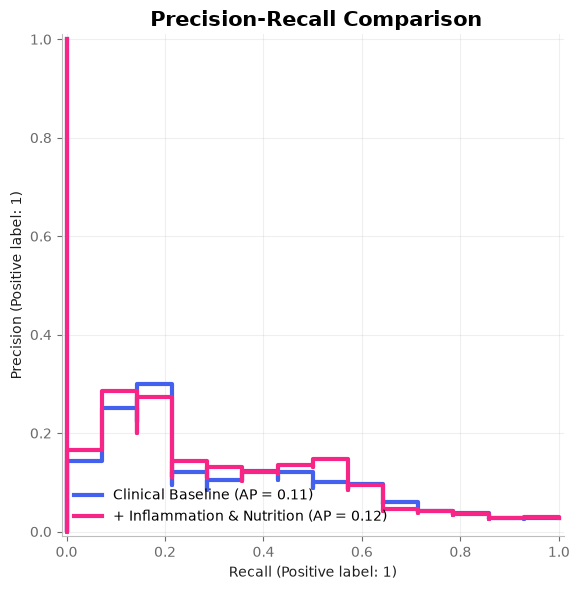

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test_q6,
    prob_base_q6,
    name="Clinical Baseline",
    ax=ax,
    color="#4361EE",
    linewidth=3
)

PrecisionRecallDisplay.from_predictions(
    y_test_q6,
    prob_full_q6,
    name="+ Inflammation & Nutrition",
    ax=ax,
    color="#F72585",
    linewidth=3
)

ax.set_title(
    " Precision-Recall Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Inflammatory and nutritional markers describe dimensions of patient health that are different from standard heart-failure severity measures. hs-CRP, WBC and NLR can capture systemic inflammatory stress, while albumin provides complementary information about nutritional and physiological reserve. Evaluating these variables as an additional feature group helps determine whether a broader systemic-health profile can strengthen mortality prediction beyond demographics, vital signs and cardiac severity alone.<br><b>What this means:</b> inflammatory and nutritional markers may be most valuable when combined with established cardiac and clinical indicators. If they add predictive information, they could help identify vulnerable patients whose risk is not fully explained by conventional heart-failure measures.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q7. Can admission-time respiratory, neurologic and clinical-status characteristics predict which patients will require mechanical ventilation or respiratory support?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>respiration, oxygen_saturation, partial_oxygen_pressure, partial_pressure_of_carbon_dioxide, fio2, gcs, consciousness, pulse, systolic_blood_pressure, body_temperature, nyha_cardiac_function_classification, killip_grade, respiratory_support_flag</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>respiratory_support_flag</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients who require invasive or non-invasive respiratory support may show evidence of respiratory compromise, neurologic impairment or cardiovascular instability. Respiratory rate, oxygen saturation, blood-gas measurements and FiO₂ describe respiratory function; GCS and consciousness provide information about neurologic status; and pulse, blood pressure, NYHA class and Killip grade describe overall clinical and cardiac severity. Combining these domains in one model allows us to test whether a high-risk respiratory-support profile can be identified from admission-time characteristics.</b></i></p>

In [32]:
features_q7 = [
    "respiration",
    "oxygen_saturation",
    "partial_oxygen_pressure",
    "partial_pressure_of_carbon_dioxide",
    "fio2",
    "gcs",
    "consciousness",
    "pulse",
    "systolic_blood_pressure",
    "body_temperature",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

target_q7 = "respiratory_support_flag"

categorical_q7 = [
    "consciousness",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

q7 = df[features_q7 + [target_q7]].copy()

q7[target_q7] = pd.to_numeric(
    q7[target_q7],
    errors="coerce"
)

q7 = q7.dropna(subset=[target_q7])

X_q7 = q7[features_q7]
y_q7 = q7[target_q7].astype(int)

print("Respiratory Support Target Distribution")
display(
    y_q7.value_counts()
        .rename(index={
            0: "No Recorded Support",
            1: "IMV / NIMV"
        })
        .to_frame("Patients")
)

X_train_q7, X_test_q7, y_train_q7, y_test_q7 = (
    train_test_split(
        X_q7,
        y_q7,
        test_size=0.25,
        random_state=42,
        stratify=y_q7
    )
)

model_q7 = build_logistic_model(
    features_q7,
    categorical_q7
)

model_q7.fit(
    X_train_q7,
    y_train_q7
)

prob_q7 = model_q7.predict_proba(
    X_test_q7
)[:, 1]

pred_q7 = model_q7.predict(
    X_test_q7
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test_q7, prob_q7),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test_q7,
            prob_q7
        ),
        3
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_q7,
        pred_q7,
        target_names=[
            "No Support",
            "IMV/NIMV"
        ],
        zero_division=0
    )
)

Respiratory Support Target Distribution


,Patients
respiratory_support_flag,
No Recorded Support,1966
IMV / NIMV,42


ROC-AUC: 0.995
PR-AUC: 0.76

Classification Report:
              precision    recall  f1-score   support

  No Support       1.00      0.98      0.99       491
    IMV/NIMV       0.53      0.91      0.67        11

    accuracy                           0.98       502
   macro avg       0.76      0.95      0.83       502
weighted avg       0.99      0.98      0.98       502



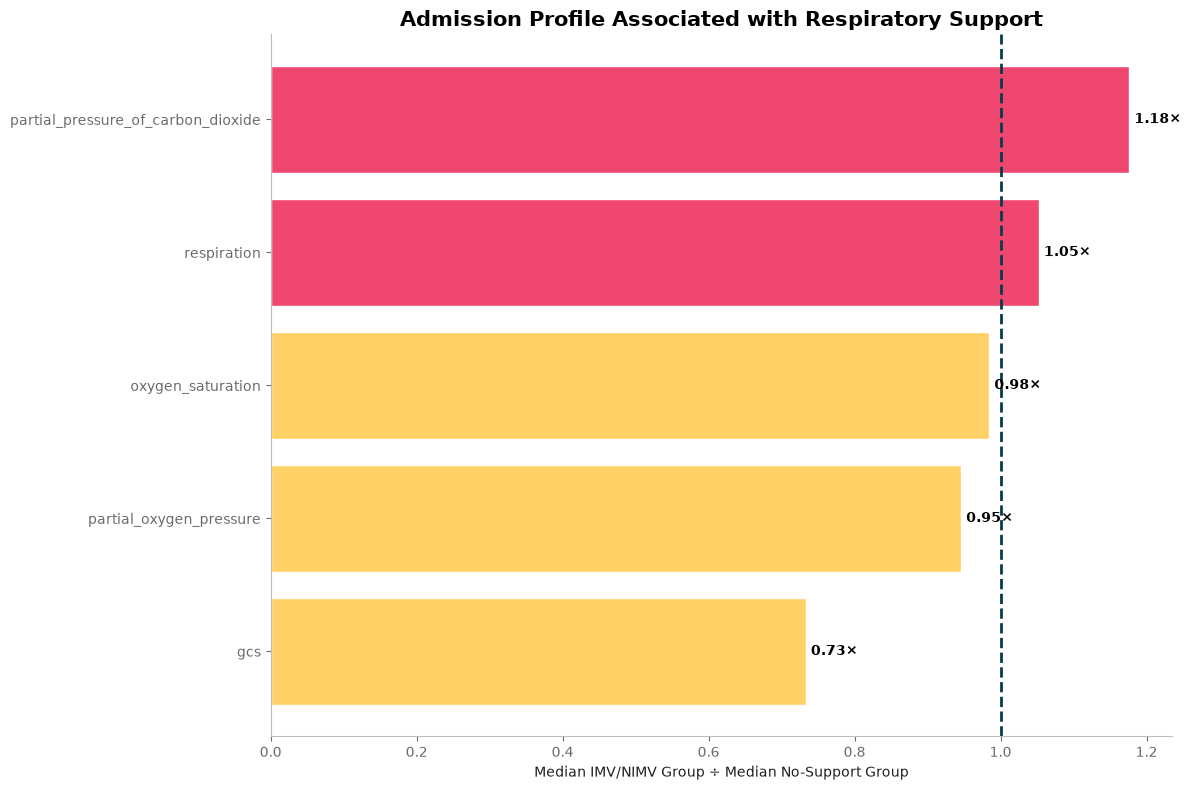

In [33]:
profile_variables_q7 = [
    "respiration",
    "oxygen_saturation",
    "partial_oxygen_pressure",
    "partial_pressure_of_carbon_dioxide",
    "gcs"
]

profile_q7 = (
    q7
    .groupby(target_q7)[profile_variables_q7]
    .median()
    .T
)

profile_q7.columns = [
    "No Recorded Support",
    "IMV / NIMV"
]

ratio_q7 = (
    profile_q7["IMV / NIMV"]
    /
    profile_q7["No Recorded Support"]
)

ratio_q7 = (
    ratio_q7
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values()
)

colors = [
    "#FFD166" if value < 1 else "#EF476F"
    for value in ratio_q7
]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    ratio_q7.index,
    ratio_q7.values,
    color=colors,
    edgecolor="white"
)

ax.axvline(
    1,
    color="#073B4C",
    linestyle="--",
    linewidth=2
)

ax.set_title(
    "Admission Profile Associated with Respiratory Support",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Median IMV/NIMV Group ÷ Median No-Support Group"
)

#ax.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, ratio_q7):
    ax.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:.2f}×",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The need for respiratory support is likely to reflect multiple dimensions of clinical instability rather than a single measurement. Respiratory and blood-gas variables describe gas exchange and ventilation, neurologic measures describe consciousness and responsiveness, and cardiovascular variables describe overall hemodynamic and heart-failure severity. A combined model can therefore identify whether these admission-time signals form a recognizable profile associated with later IMV or NIMV support.<br><b>What this means:</b> identifying a respiratory-support risk profile early could help prioritize closer respiratory monitoring and clinical reassessment. Because respiratory support is an uncommon outcome in this dataset, precision, recall and PR-AUC are particularly important when evaluating the model.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q8. Can neurologic conditions, comorbidity burden and clinical severity predict non-home discharge after hospitalization?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>dementia, cerebrovascular_disease, hemiplegia, gcs, consciousness, cci_score, comorbidity_count, agecat, nyha_cardiac_function_classification, killip_grade, respiratory_support_flag, destinationdischarge</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>Home vs HealthcareFacility</code>. Patients with an unknown discharge destination or in-hospital death are excluded from this specific predictive model.</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Discharge destination reflects whether a patient can return home or requires additional healthcare support after hospitalization. Neurologic conditions such as dementia, cerebrovascular disease and hemiplegia may reduce functional independence, while GCS and consciousness provide information about neurologic status. CCI and comorbidity count represent overall disease burden, and NYHA class, Killip grade and respiratory-support status describe clinical severity. Combining these factors allows us to evaluate whether patients who may require healthcare-facility discharge can be identified from their clinical profile.</b></i></p>

In [34]:
q8 = df[
    df["destinationdischarge"].isin([
        "Home",
        "HealthcareFacility"
    ])
].copy()

q8["non_home_discharge"] = (
    q8["destinationdischarge"]
    .eq("HealthcareFacility")
    .astype(int)
)

features_q8 = [
    "dementia",
    "cerebrovascular_disease",
    "hemiplegia",
    "gcs",
    "consciousness",
    "cci_score",
    "comorbidity_count",
    "agecat",
    "nyha_cardiac_function_classification",
    "killip_grade",
    "respiratory_support_flag"
]

categorical_q8 = [
    "consciousness",
    "agecat",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

X_q8 = q8[features_q8]
y_q8 = q8["non_home_discharge"]

print("Model Population:", len(q8))

print("\nDischarge Target Distribution:")
display(
    y_q8.value_counts()
        .rename(index={
            0: "Home",
            1: "Healthcare Facility"
        })
        .to_frame("Patients")
)

X_train_q8, X_test_q8, y_train_q8, y_test_q8 = (
    train_test_split(
        X_q8,
        y_q8,
        test_size=0.25,
        random_state=42,
        stratify=y_q8
    )
)

model_q8 = build_logistic_model(
    features_q8,
    categorical_q8
)

model_q8.fit(
    X_train_q8,
    y_train_q8
)

prob_q8 = model_q8.predict_proba(
    X_test_q8
)[:, 1]

pred_q8 = model_q8.predict(
    X_test_q8
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test_q8,
            prob_q8
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test_q8,
            prob_q8
        ),
        3
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_q8,
        pred_q8,
        target_names=[
            "Home",
            "Healthcare Facility"
        ],
        zero_division=0
    )
)

Model Population: 1782

Discharge Target Distribution:


,Patients
non_home_discharge,
Home,1344
Healthcare Facility,438


ROC-AUC: 0.519
PR-AUC: 0.286

Classification Report:
                     precision    recall  f1-score   support

               Home       0.77      0.62      0.69       336
Healthcare Facility       0.28      0.45      0.34       110

           accuracy                           0.58       446
          macro avg       0.53      0.53      0.52       446
       weighted avg       0.65      0.58      0.60       446



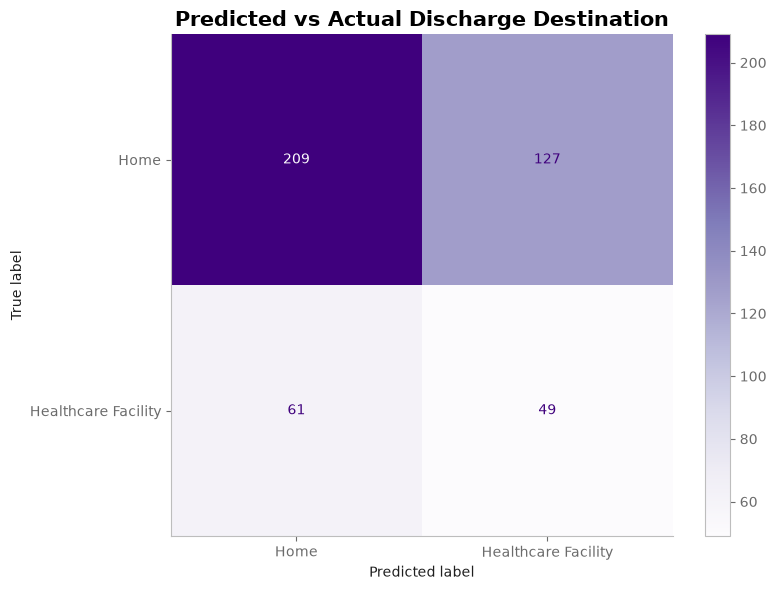

In [35]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_q8,
    pred_q8,
    display_labels=[
        "Home",
        "Healthcare Facility"
    ],
    cmap="Purples",
    values_format="d",
    ax=ax
)

ax.set_title(
    "Predicted vs Actual Discharge Destination",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

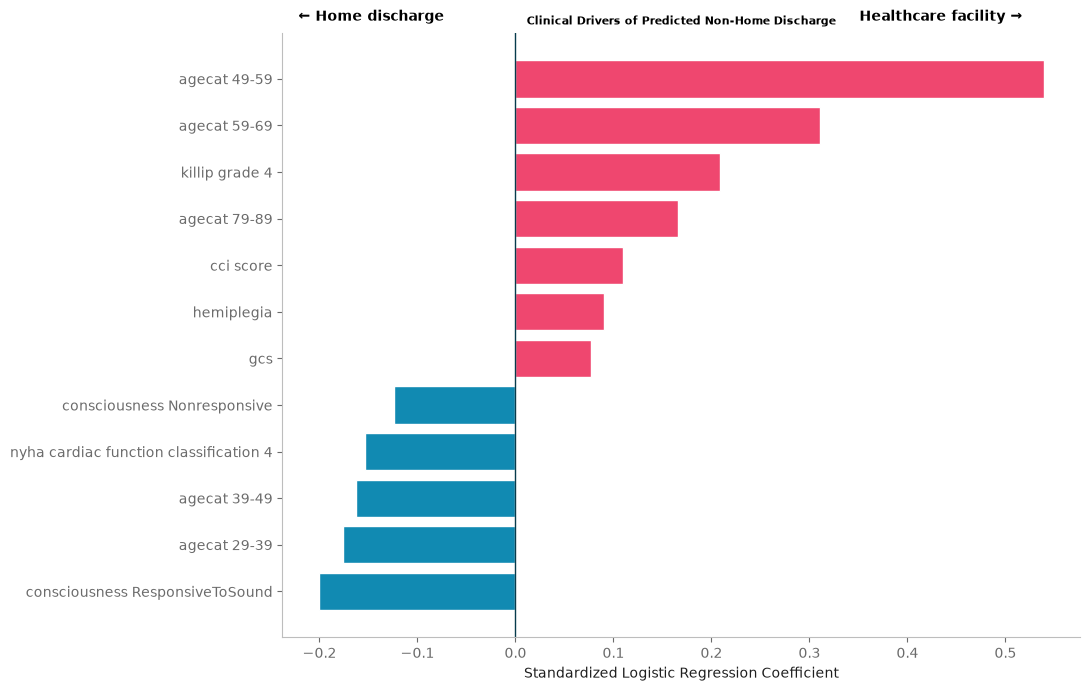

In [36]:
feature_names_q8 = (
    model_q8
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_q8 = (
    model_q8
    .named_steps["classifier"]
    .coef_[0]
)

importance_q8 = pd.DataFrame({
    "Feature": feature_names_q8,
    "Coefficient": coefficients_q8
})

# Clean labels
importance_q8["Feature"] = (
    importance_q8["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ")
)

importance_q8["Importance"] = (
    importance_q8["Coefficient"].abs()
)

top_q8 = (
    importance_q8
    .nlargest(12, "Importance")
    .sort_values("Coefficient")
)

colors = [
    "#118AB2" if value < 0 else "#EF476F"
    for value in top_q8["Coefficient"]
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    top_q8["Feature"],
    top_q8["Coefficient"],
    color=colors,
    edgecolor="white"
)

ax.axvline(
    0,
    color="#073B4C",
    linewidth=1
)

ax.set_title(
    "Clinical Drivers of Predicted Non-Home Discharge",
    fontsize=8,
    fontweight="bold"
)

ax.set_xlabel(
    "Standardized Logistic Regression Coefficient"
)

ax.text(
    0.02,
    1.02,
    "← Home discharge                                                                                   Healthcare facility →",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold"
)

"""ax.grid(
    axis="x",
    alpha=0.20
)"""

plt.tight_layout()
plt.show() 

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Non-home discharge is likely to reflect a combination of functional, neurologic and overall disease burden rather than heart-failure severity alone. Neurologic conditions may affect a patient's ability to function independently, while higher comorbidity and greater clinical severity can increase the need for continued care after hospitalization. Predictive modeling allows these factors to be evaluated together and identifies which characteristics contribute most strongly to the distinction between home and healthcare-facility discharge.<br><b>What this means:</b> an interpretable discharge-risk model could support earlier discharge planning by highlighting patients who may need rehabilitation, skilled nursing or other post-hospital support. The prediction should support clinical and care-planning decisions rather than replace individualized assessment.</b></i></p>